# fio-cmp: DAOS (dfs) vs NSF

Sequential & random read comparison across block sizes 4K / 1M / 4M.
Single job, iodepth=32. Metrics: bandwidth, IOPS, latency percentiles, CPU usage.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

RESULTS_DIR = Path(".")

BS_ORDER = ["4k", "1m", "4m"]
COLORS   = {"daos": "#1f77b4", "nsf": "#ff7f0e"}


## Multi-Run Variability — CV%

DAOS-DFS, NFS-pvsync2; sequential read, nj=1, iodepth=32.  
CV% = (std / mean) × 100 across repeated runs per block size.


In [2]:
import statistics
from IPython.display import display

def _load_fio(pattern):
    """Load fio JSON files; return DataFrame with per-run BW, lat, CPU metrics."""
    files = sorted(RESULTS_DIR.glob(pattern))
    records = []
    for fpath in files:
        with open(fpath) as f:
            d = json.load(f)
        j = d["jobs"][0]
        r = j["read"]
        records.append(dict(
            file        = fpath.name,
            bw_GiBs     = r["bw_bytes"] / (1024**3),
            iops        = r["iops"],
            lat_mean_ms = r["lat_ns"]["mean"] / 1e6,
            usr_cpu     = j["usr_cpu"],
            sys_cpu     = j["sys_cpu"],
        ))
    return pd.DataFrame(records)

_CV_CONFIGS = {
    ("DAOS-DFS",    "4k"): "dfs_seq_read_bs4k_*.json",
    ("DAOS-DFS",    "1m"): "dfs_seq_read_bs1m_*.json",
    ("DAOS-DFS",    "4m"): "dfs_seq_read_bs4m_*.json",
    ("NFS-pvsync2", "4k"): "pvsync2_nsf_seq_read_bs4k_*.json",
    ("NFS-pvsync2", "1m"): "pvsync2_nsf_seq_read_bs1m_*.json",
    ("NFS-pvsync2", "4m"): "pvsync2_nsf_seq_read_bs4m_*.json",
}

_run_data = {key: _load_fio(pat) for key, pat in _CV_CONFIGS.items()}

cv_rows = []
for (system, bs), df in _run_data.items():
    for metric, label in [("bw_GiBs", "BW (GiB/s)"), ("lat_mean_ms", "Lat (ms)")]:
        vals = df[metric].tolist()
        mu = statistics.mean(vals)
        sd = statistics.stdev(vals) if len(vals) > 1 else 0.0
        cv_rows.append(dict(System=system, bs=bs, Metric=label, N=len(vals),
                            Mean=round(mu, 4), Std=round(sd, 4), CV_pct=round(sd / mu * 100, 2)))

cv_df = pd.DataFrame(cv_rows)
pivot = cv_df.pivot_table(index=["System", "bs"], columns="Metric", values="CV_pct")
pivot.columns.name = None
pivot = pivot[["BW (GiB/s)", "Lat (ms)"]].rename(columns={"BW (GiB/s)": "BW CV%", "Lat (ms)": "Lat CV%"})

pd.set_option("display.float_format", "{:.2f}".format)
print("Multi-run CV%  (DAOS-DFS / NFS-pvsync2)\n")
display(pivot)

Multi-run CV%  (DAOS-DFS / NFS-pvsync2)



BW CV%  Lat CV%
System      bs                 
DAOS-DFS    1m   45.62    73.52
            4k    3.70     3.80
            4m   44.25    70.52
NFS-pvsync2 1m    4.27     5.15
            4k    8.35     8.65
            4m    3.68     1.03

## Multi-Run Performance: Median BW, Mean Latency & CPU Usage

DAOS-DFS vs NFS-pvsync2; sequential read, nj=1, iodepth=32.  
BW bars show **median** across repeated runs; latency bars show mean of per-run mean latency;  
CPU shows mean usr (solid) + sys (hatched) across runs.

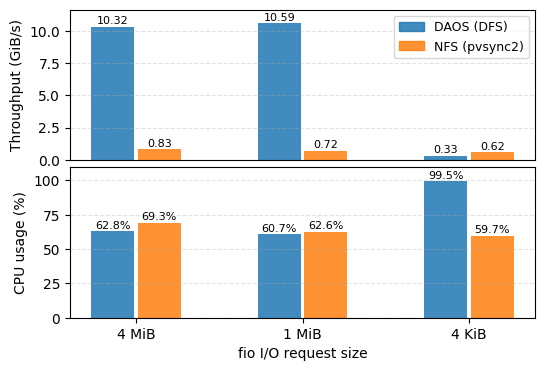

In [3]:
from matplotlib.patches import Patch

_SYSTEMS   = ["DAOS-DFS", "NFS-pvsync2"]
_DISPLAY   = ["DAOS (DFS)", "NFS (pvsync2)"]
_BS_ORDER  = ["4m", "1m", "4k"]
_BS_LABELS = ["4 MiB", "1 MiB", "4 KiB"]

tab10  = plt.colormaps["tab10"]
colors = [tab10(0), tab10(1)]

width   = 0.28
x       = np.arange(len(_BS_ORDER))
offsets = np.array([-0.5, 0.5]) * width

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
fig.subplots_adjust(hspace=0.05)

for i, (sys_, dname, color) in enumerate(zip(_SYSTEMS, _DISPLAY, colors)):
    bw_vals  = [np.median(_run_data[(sys_, bs)]["bw_GiBs"]) for bs in _BS_ORDER]
    usr_vals = [_run_data[(sys_, bs)]["usr_cpu"].mean()     for bs in _BS_ORDER]
    sys_vals = [_run_data[(sys_, bs)]["sys_cpu"].mean()     for bs in _BS_ORDER]
    cpu_vals = [u + s for u, s in zip(usr_vals, sys_vals)]

    bars_bw = ax_top.bar(x + offsets[i], bw_vals, width * 0.92, color=color, alpha=0.85, label=dname)
    for bar, v in zip(bars_bw, bw_vals):
        ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    bars_cpu = ax_bot.bar(x + offsets[i], cpu_vals, width * 0.92, color=color, alpha=0.85)
    for bar, v in zip(bars_cpu, cpu_vals):
        ax_bot.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

bw_max  = max(np.median(_run_data[(s, bs)]["bw_GiBs"]) for s in _SYSTEMS for bs in _BS_ORDER)
cpu_max = max(
    (_run_data[(s, bs)]["usr_cpu"] + _run_data[(s, bs)]["sys_cpu"]).mean()
    for s in _SYSTEMS for bs in _BS_ORDER
)

ax_top.set_ylim(0, bw_max * 1.1)
ax_top.set_ylabel("Throughput (GiB/s)", fontsize=10)
ax_top.grid(axis="y", linestyle="--", alpha=0.35)
ax_top.tick_params(bottom=False)

# Single shared legend at the top
ax_top.legend(
    handles=[Patch(color=colors[i], alpha=0.85, label=_DISPLAY[i]) for i in range(len(_SYSTEMS))],
    fontsize=9, loc="best"
)

ax_bot.set_ylim(0, cpu_max * 1.1)
ax_bot.set_ylabel("CPU usage (%)", fontsize=10)
ax_bot.grid(axis="y", linestyle="--", alpha=0.35)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(_BS_LABELS, fontsize=10)
ax_bot.set_xlabel("fio I/O request size", fontsize=10)



plt.savefig("fio-cmp_dfs-pvsync2_bw-cpu.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Network File System (NFS) Result Analysis


### pvsync2 engine, bs = 4m

10 repeated runs of `pvsync2` ioengine on NSF (seq read, bs=4M, nj=1, iodepth=32) to assess run-to-run variance.

In [4]:
import statistics

def load_nsf(pattern):
    """Load NSF fio JSON files matching glob pattern; return (per-run df, summary df)."""
    files = sorted(RESULTS_DIR.glob(pattern))
    records = []
    for fpath in files:
        with open(fpath) as f:
            d = json.load(f)
        r = d["jobs"][0]["read"]
        records.append(dict(
            file        = fpath.name,
            bw_GiBs     = r["bw_bytes"] / (1024**3),
            iops        = r["iops"],
            lat_mean_ms = r["lat_ns"]["mean"] / 1e6,
            clat_p50_ms = r["clat_ns"]["percentile"]["50.000000"] / 1e6,
        ))
    df = pd.DataFrame(records)
    summary = {}
    for col in ["bw_GiBs", "iops", "lat_mean_ms", "clat_p50_ms"]:
        vals = df[col].tolist()
        mu  = statistics.mean(vals)
        sd  = statistics.stdev(vals) if len(vals) > 1 else 0.0
        summary[col] = dict(min=min(vals), max=max(vals), mean=mu, std=sd, cv_pct=sd/mu*100)
    summary_df = pd.DataFrame(summary).T.round(4)
    summary_df.index.name = "metric"
    return df, summary_df

pv2_4m_df, pv2_4m_summary = load_nsf("pvsync2_nsf_seq_read_bs4m_*.json")
print(f"pvsync2 / bs=4m  — {len(pv2_4m_df)} runs")
print(pv2_4m_df.to_string(index=False))
print()
print(pv2_4m_summary)

pvsync2 / bs=4m  — 10 runs
                                               file  bw_GiBs   iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810430.json     0.93 237.27         4.21         4.01
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810467.json     0.82 209.69         4.25         4.05
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810507.json     0.83 213.22         4.17         3.95
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810546.json     0.83 213.44         4.16         3.98
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810586.json     0.83 213.42         4.16         3.95
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810626.json     0.84 214.32         4.14         3.95
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810665.json     0.83 212.71         4.17         3.98
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810705.json     0.84 215.99         4.11         3.92
pvsync2_nsf_seq_read_bs4m_nj1_iod32_1781810744.json     0.83 213.17         4.17         3.95
pvsync2_nsf_seq_read_bs4m_nj1_iod

---
### pvsync2 engine — bs = 4k

10 repeated runs of `pvsync2` ioengine on NFS (seq read, bs=4k, nj=1, iodepth=32).

In [5]:
pv2_4k_df, pv2_4k_summary = load_nsf("pvsync2_nsf_seq_read_bs4k_*.json")
print(f"pvsync2 / bs=4k  — {len(pv2_4k_df)} runs")
print(pv2_4k_df.to_string(index=False))
print()
print(pv2_4k_summary)

pvsync2 / bs=4k  — 10 runs
                                               file  bw_GiBs      iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159360.json     0.70 183085.44         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159406.json     0.62 162554.46         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159458.json     0.62 162469.80         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159509.json     0.62 163117.56         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159560.json     0.53 138950.99         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159620.json     0.62 163416.62         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159671.json     0.52 136295.05         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159731.json     0.62 162777.11         0.01         0.00
pvsync2_nsf_seq_read_bs4k_nj1_iod32_1782159782.json     0.62 163709.63         0.01         0.00
pvs

---
### pvsync2 engine — bs = 1m

10 repeated runs of `pvsync2` ioengine on NFS (seq read, bs=1m, nj=1, iodepth=32).

In [6]:
pv2_1m_df, pv2_1m_summary = load_nsf("pvsync2_nsf_seq_read_bs1m_*.json")
print(f"pvsync2 / bs=1m  — {len(pv2_1m_df)} runs")
print(pv2_1m_df.to_string(index=False))
print()
print(pv2_1m_summary)

pvsync2 / bs=1m  — 10 runs
                                               file  bw_GiBs   iops  lat_mean_ms  clat_p50_ms
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161076.json     0.73 743.81         1.21         1.45
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161120.json     0.71 730.24         1.24         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161166.json     0.74 757.69         1.19         1.42
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161210.json     0.63 643.67         1.42         1.71
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161260.json     0.72 732.18         1.23         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161306.json     0.72 740.86         1.22         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161350.json     0.72 735.93         1.23         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161396.json     0.72 739.73         1.22         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod32_1782161440.json     0.72 733.42         1.23         1.43
pvsync2_nsf_seq_read_bs1m_nj1_iod

---
### pvsync2 engine — throughput by timestamp

Per-run bandwidth of the NFS `pvsync2` runs plotted against each run's start timestamp
(parsed from the filename). One panel per block size — note the 4m runs are from an
earlier session (2026-06-18) than the 4k/1m runs (2026-06-22).

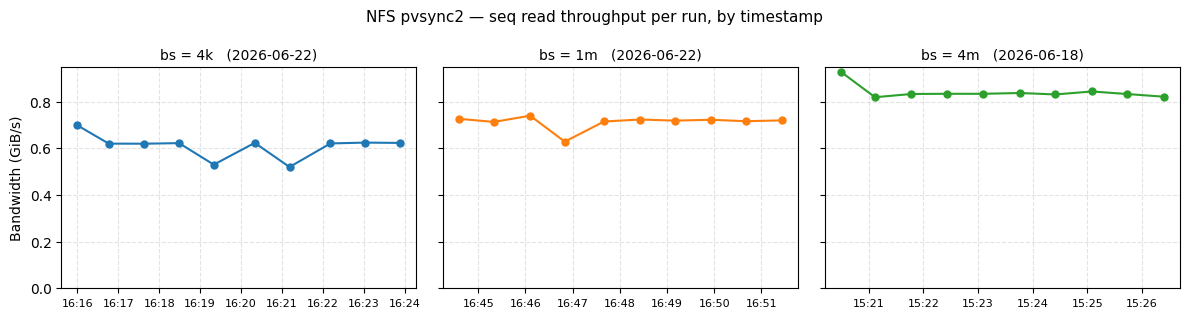

In [7]:
import datetime as dt
import matplotlib.dates as mdates

def _pv2_runs(bs):
    """Return (timestamps, bw_GiBs) for pvsync2 NFS runs of a given block size."""
    files = sorted(RESULTS_DIR.glob(f"pvsync2_nsf_seq_read_bs{bs}_*.json"))
    ts, bw = [], []
    for fpath in files:
        with open(fpath) as f:
            d = json.load(f)
        ts.append(dt.datetime.fromtimestamp(int(fpath.stem.split("_")[-1])))
        bw.append(d["jobs"][0]["read"]["bw_bytes"] / (1024**3))
    return ts, bw

_TS_BS = ["4k", "1m", "4m"]
tab10  = plt.colormaps["tab10"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, bs, color in zip(axes, _TS_BS, [tab10(0), tab10(1), tab10(2)]):
    ts, bw = _pv2_runs(bs)
    ax.plot(ts, bw, marker="o", ms=5, lw=1.5, color=color)
    ax.set_title(f"bs = {bs}   ({ts[0]:%Y-%m-%d})", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.grid(linestyle="--", alpha=0.35)
    ax.tick_params(axis="x", labelsize=8)
axes[0].set_ylabel("Bandwidth (GiB/s)", fontsize=10)
axes[0].set_ylim(0, None)
fig.suptitle("NFS pvsync2 — seq read throughput per run, by timestamp", fontsize=11)
fig.tight_layout()
plt.show()

## DAOS DFS Repeat-Run Consistency Check

60 runs total: 10 per block size (4k / 4m / 1m) for **seq read** and 10 per block size
for **rand read**; nj=1, iodepth=32, dfs ioengine. Tables are grouped by operation
(seq first, then rand), each with a mean/std/CV summary row.

In [8]:
from IPython.display import display

daos_files = sorted(RESULTS_DIR.glob("dfs_seq_read*.json"))
daos_records = []
for fpath in daos_files:
    op = fpath.stem.split("_")[1]          # "seq" or "rand" from dfs_{op}_read_...
    bs = fpath.stem.split("_bs")[1].split("_")[0]
    ts = int(fpath.stem.split("_")[-1])
    with open(fpath) as f:
        d = json.load(f)
    j = d["jobs"][0]
    r = j["read"]
    daos_records.append(dict(
        op=op, bs=bs, ts=ts,
        runtime_s  = j["job_runtime"] / 1e3,
        bw_GiBs    = r["bw_bytes"] / (1024**3),
        iops       = r["iops"],
        lat_mean_ms= r["lat_ns"]["mean"] / 1e6,
        clat_p50_ms= r["clat_ns"]["percentile"]["50.000000"] / 1e6,
        usr_cpu    = j["usr_cpu"],
        sys_cpu    = j["sys_cpu"],
    ))

daos_df = pd.DataFrame(daos_records).sort_values(["op", "bs", "ts"]).reset_index(drop=True)
daos_df["run"] = daos_df.groupby(["op", "bs"]).cumcount() + 1

COLS = ["runtime_s", "bw_GiBs", "iops", "lat_mean_ms", "clat_p50_ms", "usr_cpu", "sys_cpu"]
COL_LABELS = ["runtime (s)", "BW (GiB/s)", "IOPS", "lat_mean (ms)", "clat_p50 (ms)", "usr_cpu (%)", "sys_cpu (%)"]

for op in ["seq", "rand"]:
    for bs in ["4k", "4m", "1m"]:
        sub = daos_df[(daos_df.op == op) & (daos_df.bs == bs)][["run"] + COLS].copy()
        if sub.empty:
            continue

        # Summary row
        summary = {"run": "summary"}
        for col in COLS:
            vals = sub[col].tolist()
            mu = statistics.mean(vals)
            sd = statistics.stdev(vals)
            summary[col] = f"mean={mu:.3f}\nstd={sd:.3f}\nCV={sd/mu*100:.1f}%"

        display_df = pd.concat(
            [sub.astype(str), pd.DataFrame([summary])],
            ignore_index=True
        )
        display_df.columns = ["run"] + COL_LABELS

        print(f"\n{'='*60}")
        print(f"  {op} read — bs = {bs}  (n={len(sub)})")
        print(f"{'='*60}")
        display(display_df.style.set_properties(
            subset=["run"], **{"font-weight": "bold"}
        ).set_table_styles([
            {"selector": "tr:last-child", "props": [("background-color", "#f0f0f0"), ("font-style", "italic")]}
        ]).hide(axis="index"))


  seq read — bs = 4k  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,90.961,0.30782084818929434,80693.388448,0.396267754167,0.346112,99.189763,0.311122
2,89.48,0.3129155905917287,82028.944692,0.389806373599,0.342016,99.261287,0.286097
3,86.891,0.32223910093307495,84473.047001,0.378521258483,0.329728,99.240428,0.302678
4,85.508,0.32745091151446104,85839.29177,0.37247813434500004,0.325632,99.175516,0.31459
5,85.018,0.32933814730495214,86334.019454,0.370359219267,0.325632,99.18135,0.328166
6,82.924,0.33765450678765774,88514.103105,0.361239959694,0.31744,99.193237,0.308716
7,82.443,0.33962447196245193,89030.517685,0.35911684957100004,0.31744,99.201873,0.345693
8,82.428,0.339686275459826,89046.718995,0.35909325638600004,0.31744,99.251468,0.327559
9,82.775,0.3382622981444001,88673.431913,0.360598490176,0.31744,99.217155,0.292359
10,81.564,0.34328449610620737,89989.971189,0.355309264033,0.31744,99.206758,0.301604



  seq read — bs = 4m  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,9.756,2.8697345489636064,734.652045,43.32119603404,38.535168,60.239852,5.381304
2,2.746,10.192937749437988,2609.392064,12.029761649274999,10.682368,42.825929,18.973052
3,2.621,10.678871090523899,2733.790999,11.479939316127,10.289152,43.533003,18.008394
4,2.69,10.405053882859647,2663.693794,11.794207514788,10.682368,44.01487,17.546468
5,2.726,10.267693435773253,2628.52952,11.963718145926,10.682368,43.910492,17.608217
6,2.698,10.374212671071291,2655.798444,11.81607451409,10.682368,42.809489,19.088213
7,2.678,10.451661067083478,2675.625233,11.741165854353,10.551296,42.120986,19.268111
8,9.501,2.9467480527237058,754.367502,42.178109055385,38.535168,59.541101,5.936217
9,2.698,10.374212671071291,2655.798444,11.824699476144001,10.551296,44.069681,17.753892
10,9.439,2.9664159333333373,759.402479,41.880711444335994,38.01088,60.069923,5.678568



  seq read — bs = 1m  (n=10)


run,runtime (s),BW (GiB/s),IOPS,lat_mean (ms),clat_p50 (ms),usr_cpu (%),sys_cpu (%)
1,9.54,2.934702861122787,3005.13573,10.622027627965,8.224768,55.440252,6.436059
2,2.577,10.861132660880685,11121.799845,2.854878977888,2.37568,37.524253,22.273962
3,2.58,10.848508330062032,11108.87253,2.855868120396,2.37568,37.790698,21.821705
4,2.569,10.894941633567214,11156.420233,2.840879665144,2.342912,38.536395,20.980926
5,2.768,10.111953773535788,10354.640664,3.063252952427,2.473984,45.086705,17.268786
6,2.471,11.326860841363668,11598.705502,2.732904356724,2.21184,38.891137,21.246459
7,2.671,10.479041915386915,10730.538922,2.9563262833770003,2.473984,38.524897,21.00337
8,10.427,2.6850786339491606,2749.520522,11.612731967529001,8.716288,55.720725,5.946101
9,9.475,2.9548332626000047,3025.749261,10.550626053083,8.159232,55.641161,6.058047
10,2.618,10.691103474237025,10947.689958,2.898416191267,2.408448,38.349885,22.192513


### Consistency findings

#### bs=4k — Consistent, warming trend

| Metric | Min | Max | Mean | CV |
|---|---|---|---|---|
| runtime (s) | 81.6 | 91.0 | 85.0 | 3.8% |
| BW (GiB/s) | 0.308 | 0.343 | 0.330 | 3.7% |
| lat\_mean (ms) | 0.355 | 0.396 | 0.370 | 3.8% |
| usr\_cpu (%) | 99.2 | 99.3 | 99.2 | ~0% |
| sys\_cpu (%) | 0.29 | 0.35 | 0.31 | 5.8% |

BW rises monotonically from run 1 to run 10 as the server-side cache warms — a clean warm-up curve, not noise. CV ~3.7% once warmed. **CPU is essentially 100% user-space**, sys_cpu is negligible (<0.4%).

---

#### bs=4m — Bimodal (cache hit vs cold read)

| Run state | runtime (s) | BW (GiB/s) | lat\_mean (ms) | usr\_cpu (%) | sys\_cpu (%) |
|---|---|---|---|---|---|
| Cold (runs 1, 8, 10) | ~9.4–9.8 | ~2.87–2.97 | ~42–43 | ~59–60 | ~5–6 |
| Cached (runs 2–7, 9) | ~2.6–2.7 | ~10.2–10.7 | ~11.5–12.0 | ~42–44 | ~17–19 |

#### bs=1m — Bimodal (same pattern)

| Run state | runtime (s) | BW (GiB/s) | lat\_mean (ms) | usr\_cpu (%) | sys\_cpu (%) |
|---|---|---|---|---|---|
| Cold (runs 1, 8, 9) | ~9.5–10.4 | ~2.69–2.96 | ~10.6–11.6 | ~55–56 | ~6 |
| Cached (runs 2–7, 10) | ~2.5–2.8 | ~10.1–11.3 | ~2.7–3.1 | ~37–45 | ~17–22 |

**Bimodal cause:** the 29 GiB file does not fit entirely in the server-side cache. When the cache is warm, reads are served from DRAM/SCM at ~10–11 GiB/s; when evicted, reads fall back to NVMe at ~3 GiB/s — a ~3.5× gap.

**CPU pattern confirms the two states:**
- *Cold reads*: higher usr_cpu (~55–60%) and low sys_cpu (~5–6%). The DAOS client spends more user-space time waiting for data to arrive over the network from NVMe.
- *Cached reads*: lower usr_cpu (~38–44%) but higher sys_cpu (~17–19%). Faster data delivery means more kernel overhead per second (network interrupts, memory copies).

**Conclusion:** results for bs=4m and bs=1m are **not suitable as-is** for DAOS vs NSF comparison. Cache state must be controlled before each run (e.g. drop server-side DAOS caches or pre-warm consistently).

---
### DFS engine — throughput by timestamp

Per-run bandwidth of the DAOS DFS runs plotted against each run's start timestamp
(parsed from the filename), for **sequential (top row)** and **random (bottom row)**
reads. Panels are in chronological run order (4k → 4m → 1m) with **per-panel
y-scales** since 4k tops out well below the ~11 GiB/s that 4m/1m reach. The seq 4k
panel shows the warm-up drift; the rand 4k panel is flat (CV ~1%); the 4m and 1m
panels show the cold/cached bimodal pattern for both operations.

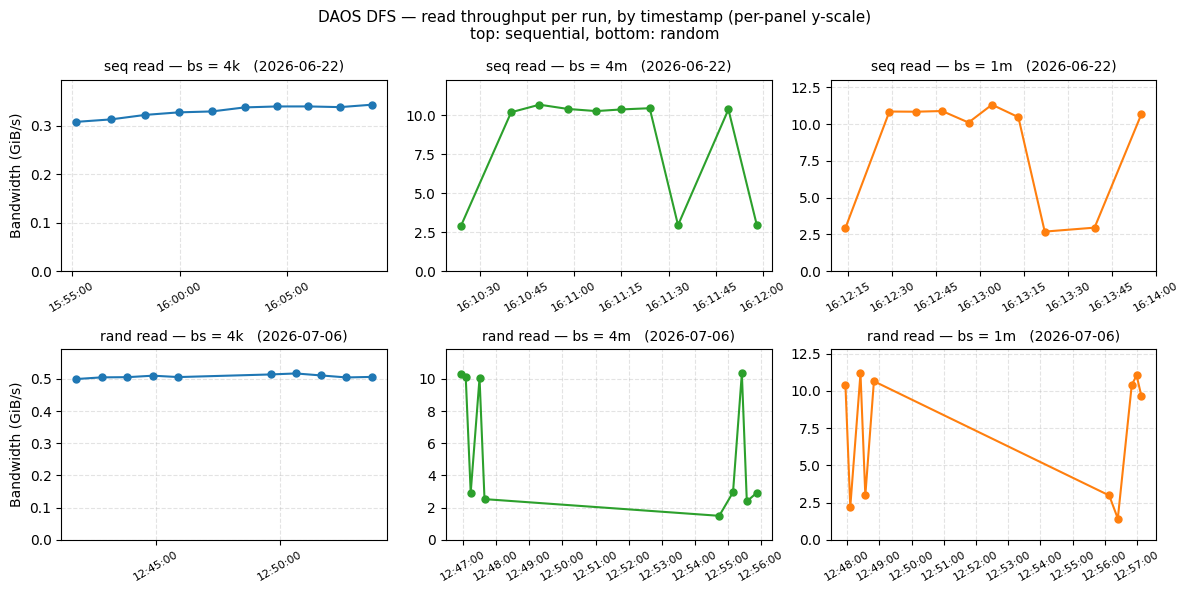

In [9]:
import datetime as dt
import matplotlib.dates as mdates

def _dfs_runs(op, bs):
    """Return (timestamps, bw_GiBs) for DAOS DFS runs of a given op (seq/rand) and block size."""
    files = sorted(RESULTS_DIR.glob(f"dfs_{op}_read_bs{bs}_*.json"))
    ts, bw = [], []
    for fpath in files:
        with open(fpath) as f:
            d = json.load(f)
        ts.append(dt.datetime.fromtimestamp(int(fpath.stem.split("_")[-1])))
        bw.append(d["jobs"][0]["read"]["bw_bytes"] / (1024**3))
    return ts, bw

# chronological run order: 4k first, then 4m, then 1m
_DFS_TS_BS = ["4k", "4m", "1m"]
tab10      = plt.colormaps["tab10"]
_BS_COLOR  = {"4k": tab10(0), "1m": tab10(1), "4m": tab10(2)}

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for row, op in enumerate(["seq", "rand"]):
    for ax, bs in zip(axes[row], _DFS_TS_BS):
        ts, bw = _dfs_runs(op, bs)
        if not ts:
            ax.set_axis_off()
            continue
        ax.plot(ts, bw, marker="o", ms=5, lw=1.5, color=_BS_COLOR[bs])
        ax.set_title(f"{op} read — bs = {bs}   ({ts[0]:%Y-%m-%d})", fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        ax.grid(linestyle="--", alpha=0.35)
        ax.tick_params(axis="x", labelsize=8, rotation=30)
        ax.set_ylim(0, max(bw) * 1.15)
    axes[row][0].set_ylabel("Bandwidth (GiB/s)", fontsize=10)
fig.suptitle("DAOS DFS — read throughput per run, by timestamp (per-panel y-scale)\n"
             "top: sequential, bottom: random", fontsize=11)
fig.tight_layout()
plt.show()

---
## I/O Queue Depth Analysis

fio reports three queue depth histograms and one depth setting per job:

| Field | What it measures |
|---|---|
| `iodepth_level` | % of time the queue had exactly N I/Os in flight simultaneously |
| `iodepth_submit` | % of submission calls that submitted 1–N I/Os at once |
| `iodepth_complete` | % of completion calls that reaped 1–N I/Os at once |
| `latency_depth` | The configured `iodepth` value (32 in all these runs) |

### Bucket label encoding

**Bucket labels are upper bounds of ranges**, not exact counts:

| Bucket key | Actual range of IOs per call |
|---|---|
| `"0"` | 0 IOs |
| `"4"` | 1–4 IOs |
| `"8"` | 5–8 IOs |
| `"16"` | 9–16 IOs |
| `"32"` | 17–32 IOs |
| `">=64"` | 33+ IOs |

So **"100% at '4'"** means every call processed somewhere between 1 and 4 IOs — most often exactly 1.

### Why DFS shows `iodepth_submit/complete = "4"` despite `iodepth=32`

It seems paradoxical that DFS keeps 32 IOs in-flight (`iodepth_level ~100% at 32`) yet submits/completes only 1–4 at a time. The mechanism is a **steady-state trickle**:

1. FIO fills the queue to 32 at startup (an initial burst).
2. Once full, each completion-reaping call harvests however many completions have arrived — typically **1–4 at a time** because completions stagger as they return from the network/storage.
3. FIO immediately re-submits **exactly that many** new IOs to top the queue back to 32.

The queue depth stays pinned at 32, but the drip rate of individual submit/complete calls is 1–4, so both fall in bucket `"4"`.

### What the distributions reveal per engine type

| Engine | iodepth_level | iodepth_submit | iodepth_complete | Interpretation |
|---|---|---|---|---|
| **DFS** | ~100% at 32 | 100% at "4" (1–4) | ~100% at "4", trace at 32 | Full async: 32 IOs in-flight, refilled 1–4 at a time as completions trickle in — the DAOS client runs its own async I/O path |
| **pvsync2** | 100% at 1 | 100% at "4" (1) | 100% at "4" (1) | Fully synchronous: 1 I/O in-flight at a time, submit–wait–complete per I/O |

> The `iodepth=32` setting in the fio job file is **not utilized** by the synchronous pvsync2 engine — its effective iodepth is 1.  
> DFS actually exploits it, keeping 32 I/Os in-flight at all times.


In [10]:
import statistics

IODEPTH_CONFIGS = [
    ("DFS",     "4k", "dfs_seq_read_bs4k_*.json"),
    ("DFS",     "1m", "dfs_seq_read_bs1m_*.json"),
    ("DFS",     "4m", "dfs_seq_read_bs4m_*.json"),
    ("pvsync2", "4k", "pvsync2_nsf_seq_read_bs4k_*.json"),
    ("pvsync2", "1m", "pvsync2_nsf_seq_read_bs1m_*.json"),
    ("pvsync2", "4m", "pvsync2_nsf_seq_read_bs4m_*.json"),
]

LEVEL_KEYS    = ["1", "2", "4", "8", "16", "32", ">=64"]
SUBMIT_KEYS   = ["0", "4", "8", "16", "32", "64", ">=64"]

rows = []
for engine, bs, pat in IODEPTH_CONFIGS:
    files = sorted(RESULTS_DIR.glob(pat))
    if not files:
        continue
    levels, submits, completes = {}, {}, {}
    for fpath in files:
        d = json.load(open(fpath))
        j = d["jobs"][0]
        for k, v in j["iodepth_level"].items():
            levels.setdefault(k, []).append(v)
        for k, v in j["iodepth_submit"].items():
            submits.setdefault(k, []).append(v)
        for k, v in j["iodepth_complete"].items():
            completes.setdefault(k, []).append(v)
    rows.append((engine, bs, len(files), levels, submits, completes))

# ── iodepth_level heatmap (% time at each depth) ──────────────────────────
print("iodepth_level  — % of time queue held exactly N IOs in-flight")
hdr = f"{'Engine':>8} {'bs':>3}  {'n':>3}  " + "  ".join(f"{k:>6}" for k in LEVEL_KEYS)
print(hdr)
print("─" * len(hdr))
for engine, bs, n, levels, submits, completes in rows:
    row = f"{engine:>8} {bs:>3}  {n:>3}  "
    for k in LEVEL_KEYS:
        if k in levels:
            m = statistics.mean(levels[k])
            row += f"  {m:>6.1f}"
        else:
            row += f"  {'—':>6}"
    print(row)

print()
print("iodepth_submit — % of submission calls that sent 1..N IOs at once")
hdr2 = f"{'Engine':>8} {'bs':>3}  {'n':>3}  " + "  ".join(f"{k:>6}" for k in SUBMIT_KEYS)
print(hdr2)
print("─" * len(hdr2))
for engine, bs, n, levels, submits, completes in rows:
    row = f"{engine:>8} {bs:>3}  {n:>3}  "
    for k in SUBMIT_KEYS:
        if k in submits:
            m = statistics.mean(submits[k])
            row += f"  {m:>6.1f}" if m > 0.001 else f"  {'0.0':>6}"
        else:
            row += f"  {'—':>6}"
    print(row)


iodepth_level  — % of time queue held exactly N IOs in-flight
  Engine  bs    n       1       2       4       8      16      32    >=64
─────────────────────────────────────────────────────────────────────────
     DFS  4k   10       0.1     0.1     0.1     0.1     0.1   100.0     0.0
     DFS  1m   10       0.1     0.1     0.1     0.1     0.1    99.9     0.0
     DFS  4m   10       0.1     0.1     0.1     0.1     0.2    99.6     0.0
 pvsync2  4k   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
 pvsync2  1m   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0
 pvsync2  4m   10     100.0     0.0     0.0     0.0     0.0     0.0     0.0

iodepth_submit — % of submission calls that sent 1..N IOs at once
  Engine  bs    n       0       4       8      16      32      64    >=64
─────────────────────────────────────────────────────────────────────────
     DFS  4k   10       0.0   100.0     0.0     0.0     0.0     0.0     0.0
     DFS  1m   10       0.0   100.0     0.0

---
## Random Read Results — N & CV% per Configuration

Available rand-read data (nj=1, iodepth=32): DAOS-DFS at 4k / 1m / 4m (10 runs each)
and NFS-pvsync2 at 4k (5 runs), 1m (11 runs), 4m (11 runs).
Reuses `_load_fio` from the seq-read CV section above.


In [11]:
_RAND_CONFIGS = {
    ("DAOS-DFS",    "4k"): "dfs_rand_read_bs4k_*.json",
    ("DAOS-DFS",    "1m"): "dfs_rand_read_bs1m_*.json",
    ("DAOS-DFS",    "4m"): "dfs_rand_read_bs4m_*.json",
    ("NFS-pvsync2", "4k"): "pvsync2_nsf_rand_read_bs4k_*.json",
    ("NFS-pvsync2", "1m"): "pvsync2_nsf_rand_read_bs1m_*.json",
    ("NFS-pvsync2", "4m"): "pvsync2_nsf_rand_read_bs4m_*.json",
}

_rand_data = {key: _load_fio(pat) for key, pat in _RAND_CONFIGS.items()}

rand_cv_rows = []
for (system, bs), df in _rand_data.items():
    for metric, label in [("bw_GiBs", "BW (GiB/s)"), ("lat_mean_ms", "Lat (ms)")]:
        vals = df[metric].tolist()
        mu = statistics.mean(vals)
        sd = statistics.stdev(vals) if len(vals) > 1 else 0.0
        rand_cv_rows.append(dict(System=system, bs=bs, Metric=label, N=len(vals),
                                 Mean=round(mu, 4), Std=round(sd, 4),
                                 CV_pct=round(sd / mu * 100, 2)))

rand_cv_df = pd.DataFrame(rand_cv_rows)
print("Random read — N and CV% per configuration\n")
display(rand_cv_df)

print("\nPer-run BW (GiB/s):")
for (system, bs), df in _rand_data.items():
    print(f"  {system:<12} {bs:<3} " + "  ".join(f"{v:6.3f}" for v in df["bw_GiBs"]))

Random read — N and CV% per configuration



,System,bs,Metric,N,Mean,Std,CV_pct
0,DAOS-DFS,4k,BW (GiB/s),10,0.51,0.01,1.00
1,DAOS-DFS,4k,Lat (ms),10,0.24,0.00,1.00
2,DAOS-DFS,1m,BW (GiB/s),10,7.29,4.25,58.31
3,DAOS-DFS,1m,Lat (ms),10,7.45,6.60,88.62
4,DAOS-DFS,4m,BW (GiB/s),10,5.60,3.98,71.10
5,DAOS-DFS,4m,Lat (ms),10,35.94,23.84,66.33
6,NFS-pvsync2,4k,BW (GiB/s),10,0.02,0.00,3.60
7,NFS-pvsync2,4k,Lat (ms),10,0.16,0.01,3.49
8,NFS-pvsync2,1m,BW (GiB/s),11,0.46,0.04,9.84
9,NFS-pvsync2,1m,Lat (ms),11,2.03,0.23,11.42



Per-run BW (GiB/s):
  DAOS-DFS     4k   0.500   0.505   0.506   0.510   0.506   0.514   0.517   0.511   0.505   0.506
  DAOS-DFS     1m  10.386   2.205  11.169   2.983  10.646   2.977   1.428  10.409  11.032   9.635
  DAOS-DFS     4m  10.324  10.112   2.932  10.054   2.529   1.491   2.951  10.340   2.389   2.922
  NFS-pvsync2  4k   0.024   0.023   0.023   0.022   0.024   0.023   0.023   0.023   0.025   0.023
  NFS-pvsync2  1m   0.384   0.393   0.477   0.481   0.487   0.480   0.383   0.476   0.469   0.490   0.489
  NFS-pvsync2  4m   0.461   0.435   0.468   0.459   0.461   0.478   0.485   0.486   0.475   0.444   0.469


### Random vs sequential read

Per configuration: median BW across runs (robust to the DFS bimodality) and mean of
per-run mean latency, for seq vs rand, plus the rand/seq BW ratio.

In [12]:
rs_rows = []
for (system, bs), rand_df in _rand_data.items():
    seq_df = _run_data[(system, bs)]
    seq_bw,  rand_bw  = np.median(seq_df["bw_GiBs"]), np.median(rand_df["bw_GiBs"])
    seq_lat, rand_lat = seq_df["lat_mean_ms"].mean(), rand_df["lat_mean_ms"].mean()
    rs_rows.append(dict(
        System=system, bs=bs,
        seq_N=len(seq_df), rand_N=len(rand_df),
        seq_BW_med=round(seq_bw, 3), rand_BW_med=round(rand_bw, 3),
        rand_over_seq=round(rand_bw / seq_bw, 2),
        seq_lat_ms=round(seq_lat, 3), rand_lat_ms=round(rand_lat, 3),
    ))

rs_df = pd.DataFrame(rs_rows)
print("Random vs sequential read — median BW (GiB/s), mean latency (ms)\n")
display(rs_df)

Random vs sequential read — median BW (GiB/s), mean latency (ms)



,System,bs,seq_N,rand_N,seq_BW_med,rand_BW_med,rand_over_seq,seq_lat_ms,rand_lat_ms
0,DAOS-DFS,4k,10,10,0.33,0.51,1.52,0.37,0.24
1,DAOS-DFS,1m,10,10,10.59,10.01,0.95,5.30,7.45
2,DAOS-DFS,4m,10,10,10.32,2.94,0.29,21.00,35.94
3,NFS-pvsync2,4k,10,10,0.62,0.02,0.04,0.01,0.16
4,NFS-pvsync2,1m,10,11,0.72,0.48,0.66,1.24,2.03
5,NFS-pvsync2,4m,10,11,0.83,0.47,0.56,4.18,7.85


### Rand vs seq findings

#### DAOS-DFS, bs=4k — rand is *faster* than seq (1.52×), and extremely stable

Rand read: 0.506 GiB/s median, CV 1.0%; seq read: 0.333 GiB/s median, CV 3.7%.
Mean latency 0.240 ms (rand) vs 0.370 ms (seq). The seq 4k runs were climbing a
warm-up curve (BW rose monotonically run 1→10); the rand runs came later against a
warm server-side cache. CPU is pinned at ~99.4% usr in both — the 4k workload is
client-CPU-bound, which also explains the tiny CV.

#### DAOS-DFS, bs=1m / 4m — same cold/cached bimodality as seq

Runs split into the same two modes seen in seq read: cached ~10–11 GiB/s
(runtime ~2.5–2.9 s, usr ~37–44%, sys ~17–23%) vs cold ~1.4–3 GiB/s
(runtime ~9–20 s, usr ~55–61%, sys ~3–7%). This makes BW CV% huge (58% at 1m,
71% at 4m) and the median unstable: the 4m "rand/seq = 0.29" is a mode-sampling
artifact (6/10 rand runs landed cold vs 3/10 seq runs), not a real rand penalty.
Within matching modes, rand ≈ seq — randomness costs DAOS essentially nothing at
large block sizes. As with seq, these runs need controlled cache state before use
in a paper figure.

#### NFS-pvsync2, bs=4k — rand collapses to ~6,100 IOPS (27× below seq)

N=5, ~20 min/run. Rand: 0.023 GiB/s median (CV 4.3%), ~6,100 IOPS, lat 0.162 ms;
seq: 0.62 GiB/s, lat ~0.006 ms, runtime ~50 s. Seq 4k on NFS is served by client
readahead + page cache; rand 4k defeats both, so every I/O pays a synchronous NFS
round trip (pvsync2 holds only 1 I/O in flight → IOPS ≈ 1/RTT). CPU flips
accordingly: usr <1%, sys ~6% — the client is idle waiting on the network.

#### NFS-pvsync2, bs=1m — rand at 0.66× of seq

Rand: 0.478 GiB/s median, CV 9.8% (N=11); seq: 0.719 GiB/s median, CV 4.3%.
Mean latency 2.03 ms vs 1.24 ms. The rand runs are mildly bimodal: 3 of 11 runs
sit at ~0.38–0.39 GiB/s, the other 8 at ~0.47–0.49 GiB/s.

#### NFS-pvsync2, bs=4m — rand at 0.56× of seq

Rand: 0.468 GiB/s median, CV 3.4% (N=11); seq: 0.833 GiB/s median, CV 3.7%.
Mean latency 7.85 ms vs 4.18 ms.

**Why NFS loses ~35–45% BW at large block sizes:** sequential reads let the
client's readahead pipeline NFS READ requests ahead of the application, hiding
round trips even though pvsync2 issues one syscall at a time. Random offsets
defeat readahead, so each 1m/4m read is split into rsize-limited NFS READs
issued with little overlap, and every request pays closer to a full round trip
(latency roughly doubles at both sizes). sys CPU drops from ~63–69% (seq) to
~41–42% (rand), consistent with the client idling on network waits rather than
moving data.

**Net:** NFS pays a real randomness penalty at every block size — catastrophic
at 4k (27×, readahead/page-cache loss) and substantial at 1m/4m (~1.5–1.8×,
readahead pipelining loss). DAOS-DFS pays essentially none: rand ≈ seq at 1m/4m
(mode-matched), and rand 4k is actually *faster* — ~133k IOPS vs NFS's ~6.1k (≈22×).


---
## DAOS-DFS: Seq vs Rand Read — BW & CPU by Block Size

Median BW across runs (bars) with per-run values overlaid as dots — the dots expose
the cold/cached bimodality at 1m/4m that the median alone hides. CPU bars show mean
usr+sys across runs. Same layout/style as the DAOS-vs-NFS figure above.
Requires `_run_data` (seq CV cell) and `_rand_data` (rand CV cell) to be defined.

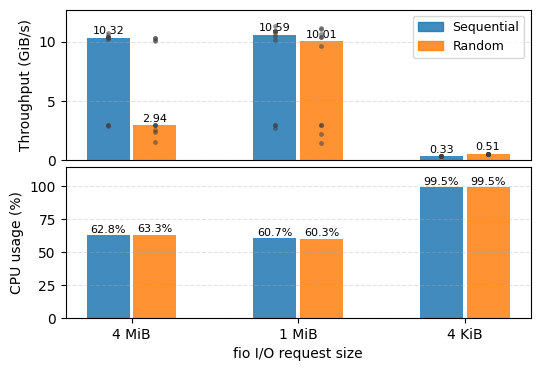

In [13]:
from matplotlib.patches import Patch

_OPS       = ["seq", "rand"]
_OP_LABEL  = {"seq": "Sequential", "rand": "Random"}
_OP_DATA   = {
    "seq":  {bs: _run_data[("DAOS-DFS", bs)]  for bs in ["4m", "1m", "4k"]},
    "rand": {bs: _rand_data[("DAOS-DFS", bs)] for bs in ["4m", "1m", "4k"]},
}
_BS_ORDER  = ["4m", "1m", "4k"]
_BS_LABELS = ["4 MiB", "1 MiB", "4 KiB"]

tab10      = plt.colormaps["tab10"]
_OP_COLOR  = {"seq": tab10(0), "rand": tab10(1)}

width   = 0.28
x       = np.arange(len(_BS_ORDER))
offsets = {"seq": -0.5 * width, "rand": 0.5 * width}

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
fig.subplots_adjust(hspace=0.05)

for op in _OPS:
    data, color = _OP_DATA[op], _OP_COLOR[op]
    bw_med   = [np.median(data[bs]["bw_GiBs"]) for bs in _BS_ORDER]
    cpu_mean = [(data[bs]["usr_cpu"] + data[bs]["sys_cpu"]).mean() for bs in _BS_ORDER]

    bars_bw = ax_top.bar(x + offsets[op], bw_med, width * 0.92,
                         color=color, alpha=0.85, label=_OP_LABEL[op])
    for bar, v in zip(bars_bw, bw_med):
        ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    # per-run dots: at 1m/4m runs split into cold (~1.5-3 GiB/s) and cached (~10-11 GiB/s) modes
    for xi, bs in zip(x, _BS_ORDER):
        vals = data[bs]["bw_GiBs"]
        ax_top.scatter(np.full(len(vals), xi + offsets[op]), vals,
                       s=12, color="0.25", alpha=0.55, zorder=3, linewidths=0)

    bars_cpu = ax_bot.bar(x + offsets[op], cpu_mean, width * 0.92, color=color, alpha=0.85)
    for bar, v in zip(bars_cpu, cpu_mean):
        ax_bot.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

bw_all_max = max(_OP_DATA[op][bs]["bw_GiBs"].max() for op in _OPS for bs in _BS_ORDER)
cpu_max = max((_OP_DATA[op][bs]["usr_cpu"] + _OP_DATA[op][bs]["sys_cpu"]).mean()
              for op in _OPS for bs in _BS_ORDER)

ax_top.set_ylim(0, bw_all_max * 1.12)
ax_top.set_ylabel("Throughput (GiB/s)", fontsize=10)
ax_top.grid(axis="y", linestyle="--", alpha=0.35)
ax_top.tick_params(bottom=False)
ax_top.legend(
    handles=[Patch(color=_OP_COLOR[op], alpha=0.85, label=_OP_LABEL[op]) for op in _OPS],
    fontsize=9, loc="upper right"
)

ax_bot.set_ylim(0, cpu_max * 1.15)
ax_bot.set_ylabel("CPU usage (%)", fontsize=10)
ax_bot.grid(axis="y", linestyle="--", alpha=0.35)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(_BS_LABELS, fontsize=10)
ax_bot.set_xlabel("fio I/O request size", fontsize=10)

plt.savefig("fio-cmp_dfs_seq-rand_bw-cpu.pdf", dpi=150, bbox_inches="tight")
plt.show()

---
## NFS-pvsync2: Seq vs Rand Read — BW & CPU by Block Size

Same layout as the DAOS seq-vs-rand figure above: median BW bars with per-run
values overlaid as dots, and mean usr+sys CPU bars. The 4k rand bar is barely
visible (~0.02 GiB/s) — the 27× seq/rand gap at 4k dominates the scale.
Requires `_run_data` (seq CV cell) and `_rand_data` (rand CV cell).


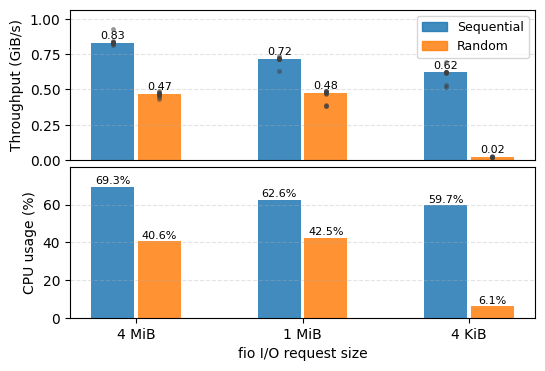

In [14]:
from matplotlib.patches import Patch

_OPS       = ["seq", "rand"]
_OP_LABEL  = {"seq": "Sequential", "rand": "Random"}
_OP_DATA   = {
    "seq":  {bs: _run_data[("NFS-pvsync2", bs)]  for bs in ["4m", "1m", "4k"]},
    "rand": {bs: _rand_data[("NFS-pvsync2", bs)] for bs in ["4m", "1m", "4k"]},
}
_BS_ORDER  = ["4m", "1m", "4k"]
_BS_LABELS = ["4 MiB", "1 MiB", "4 KiB"]

tab10      = plt.colormaps["tab10"]
_OP_COLOR  = {"seq": tab10(0), "rand": tab10(1)}

width   = 0.28
x       = np.arange(len(_BS_ORDER))
offsets = {"seq": -0.5 * width, "rand": 0.5 * width}

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
fig.subplots_adjust(hspace=0.05)

bw_all_max = max(_OP_DATA[op][bs]["bw_GiBs"].max() for op in _OPS for bs in _BS_ORDER)

for op in _OPS:
    data, color = _OP_DATA[op], _OP_COLOR[op]
    bw_med   = [np.median(data[bs]["bw_GiBs"]) for bs in _BS_ORDER]
    cpu_mean = [(data[bs]["usr_cpu"] + data[bs]["sys_cpu"]).mean() for bs in _BS_ORDER]

    bars_bw = ax_top.bar(x + offsets[op], bw_med, width * 0.92,
                         color=color, alpha=0.85, label=_OP_LABEL[op])
    for bar, v in zip(bars_bw, bw_med):
        ax_top.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + bw_all_max * 0.015,
                    f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    for xi, bs in zip(x, _BS_ORDER):
        vals = data[bs]["bw_GiBs"]
        ax_top.scatter(np.full(len(vals), xi + offsets[op]), vals,
                       s=12, color="0.25", alpha=0.55, zorder=3, linewidths=0)

    bars_cpu = ax_bot.bar(x + offsets[op], cpu_mean, width * 0.92, color=color, alpha=0.85)
    for bar, v in zip(bars_cpu, cpu_mean):
        ax_bot.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

cpu_max = max((_OP_DATA[op][bs]["usr_cpu"] + _OP_DATA[op][bs]["sys_cpu"]).mean()
              for op in _OPS for bs in _BS_ORDER)

ax_top.set_ylim(0, bw_all_max * 1.15)
ax_top.set_ylabel("Throughput (GiB/s)", fontsize=10)
ax_top.grid(axis="y", linestyle="--", alpha=0.35)
ax_top.tick_params(bottom=False)
ax_top.legend(
    handles=[Patch(color=_OP_COLOR[op], alpha=0.85, label=_OP_LABEL[op]) for op in _OPS],
    fontsize=9, loc="upper right"
)

ax_bot.set_ylim(0, cpu_max * 1.15)
ax_bot.set_ylabel("CPU usage (%)", fontsize=10)
ax_bot.grid(axis="y", linestyle="--", alpha=0.35)
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(_BS_LABELS, fontsize=10)
ax_bot.set_xlabel("fio I/O request size", fontsize=10)

# plt.savefig("fio-cmp_nsf_seq-rand_bw-cpu.pdf", dpi=150, bbox_inches="tight")
plt.show()
